<a href="https://colab.research.google.com/github/MinaSaad77/Manufacturing-Downtime-Analysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Los Angeles skyline](la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World!

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [14]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", on_bad_lines='skip')
crimes.head()

/tmp/ipykernel_16011/1156524731.py:7: DtypeWarning: Columns (0,3,6) have mixed types. Specify dtype option on import or set low_memory=False.
  crimes = pd.read_csv("crimes.csv", on_bad_lines='skip')


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110.0,Southwest,THEFT OF IDENTITY,27.0,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620.0,Olympic,THEFT OF IDENTITY,60.0,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200.0,Hollywood,THEFT OF IDENTITY,28.0,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,635.0,77th Street,THEFT OF IDENTITY,37.0,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,900.0,Rampart,THEFT OF IDENTITY,79.0,M,B,NaN,Invest Cont,1200 W 7TH ST


In [ ]:
# Start coding here
# Use as many cells as you need

In [15]:
crimes.isna().sum()

,0
DR_NO,0
Date Rptd,1
DATE OCC,3
TIME OCC,4
AREA NAME,4
Crm Cd Desc,5
Vict Age,8
Vict Sex,25
Vict Descent,26
Weapon Desc,193455


In [17]:
crimes.shape

(321525, 12)

In [27]:
# replace blank values with null
crimes['Weapon Desc'] = crimes['Weapon Desc'].replace(np.nan, 'no weapon')

In [22]:
crimes['Weapon Desc'].value_counts()

,count
Weapon Desc,
"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",69431
UNKNOWN WEAPON/OTHER WEAPON,12910
VERBAL THREAT,10317
HAND GUN,7726
KNIFE WITH BLADE 6INCHES OR LESS,2814
...,...
BOWIE KNIFE,2
Invest Cont,1
RELIC FIREARM,1


In [28]:
crimes['Weapon Desc'].head()

,Weapon Desc
0,no weapon
1,no weapon
2,no weapon
3,no weapon
4,no weapon


In [30]:
crimes['Vict Sex'] = crimes['Vict Sex'].replace('H', 'unknown')
crimes['Vict Sex'].value_counts('H')

,proportion
Vict Sex,
M,0.500793
F,0.483683
X,0.015341
unknown,0.000171
Adult Other,0.000003
"FEET OR BODILY FORCE)""",0.000003
Invest Cont,0.000003
ROCK/THROWN OBJECT,0.000003


In [34]:
crimes['Vict Sex'] = crimes['Vict Sex'].replace('X', np.nan)
crimes['Vict Sex'].value_counts('X')

,proportion
Vict Sex,
M,0.508595
F,0.491218
unknown,0.000174
Adult Other,0.000003
"FEET OR BODILY FORCE)""",0.000003
Invest Cont,0.000003
ROCK/THROWN OBJECT,0.000003


In [35]:
crimes['Vict Sex'] = crimes['Vict Sex'].replace('X', np.nan)
crimes['Vict Sex'].value_counts(np.nan)

,proportion
Vict Sex,
M,0.508595
F,0.491218
unknown,0.000174
Adult Other,0.000003
"FEET OR BODILY FORCE)""",0.000003
Invest Cont,0.000003
ROCK/THROWN OBJECT,0.000003


In [36]:
crimes['Vict Sex'] = crimes['Vict Sex'].replace(np.nan, 'unknown')
crimes['Vict Sex'].value_counts('unknown')

,proportion
Vict Sex,
M,0.500754
F,0.483645
unknown,0.015588
Adult Other,0.000003
"FEET OR BODILY FORCE)""",0.000003
Invest Cont,0.000003
ROCK/THROWN OBJECT,0.000003


In [37]:
crimes['Vict Sex'] = crimes['Vict Sex'].replace(' ', 'unknown')
crimes['Vict Sex'].value_counts('unknown')

,proportion
Vict Sex,
M,0.500754
F,0.483645
unknown,0.015588
Adult Other,0.000003
"FEET OR BODILY FORCE)""",0.000003
Invest Cont,0.000003
ROCK/THROWN OBJECT,0.000003


In [39]:
crimes = crimes.drop_duplicates()

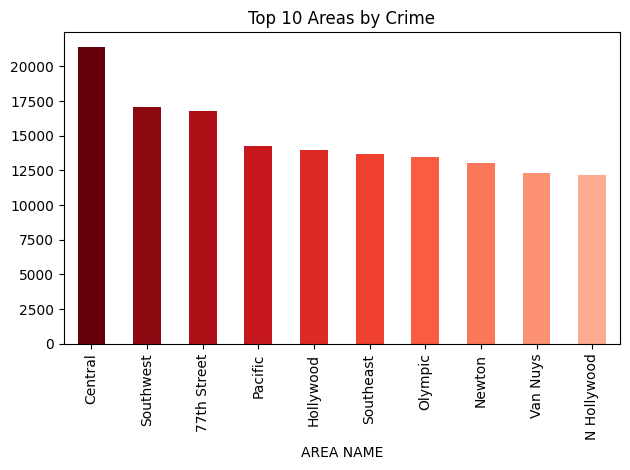

In [46]:
counts = crimes['AREA NAME'].value_counts().head(10)
colors = plt.cm.Reds(np.linspace(1,0.3, len(counts)))
counts.plot(kind='bar', color=colors, title='Top 10 Areas by Crime')
plt.tight_layout()
plt.show()

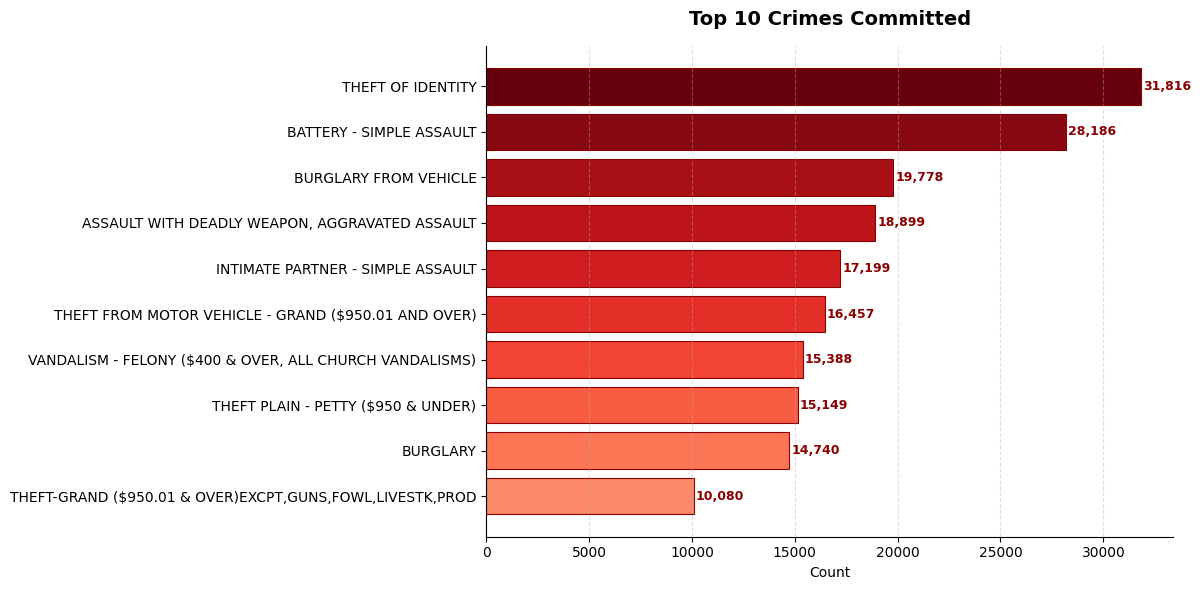

In [78]:
counts = crimes['Crm Cd Desc'].value_counts().head(10).sort_values()
colors = plt.cm.Reds(np.linspace(0.4, 1, len(counts)))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='darkred', linewidth=0.8)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold', color='darkred')

ax.set_title('Top 10 Crimes Committed', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Count')
ax.set_ylabel('')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

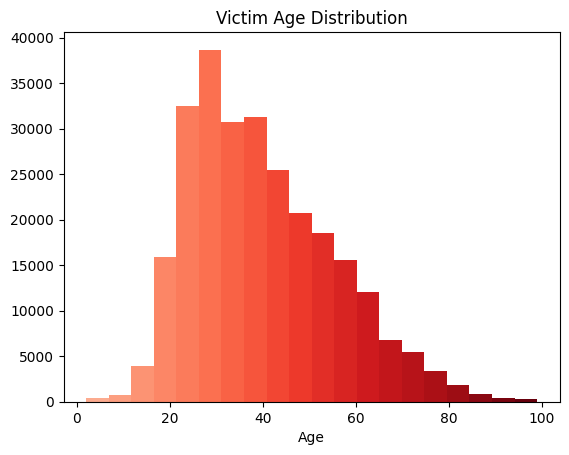

In [63]:
crimes['Vict Age'] = pd.to_numeric(crimes['Vict Age'], errors='coerce')
df_clean = crimes.dropna(subset=['Vict Age'])
df_clean = df_clean[(df_clean['Vict Age'] > 0) & (df_clean['Vict Age'] <= 99)]
counts, edges, patches = plt.hist(df_clean['Vict Age'], bins=20)
for patch, color in zip(patches, plt.cm.Reds(np.linspace(0.3, 1, len(patches)))):
    patch.set_facecolor(color)
plt.title('Victim Age Distribution')
plt.xlabel('Age')
plt.show()

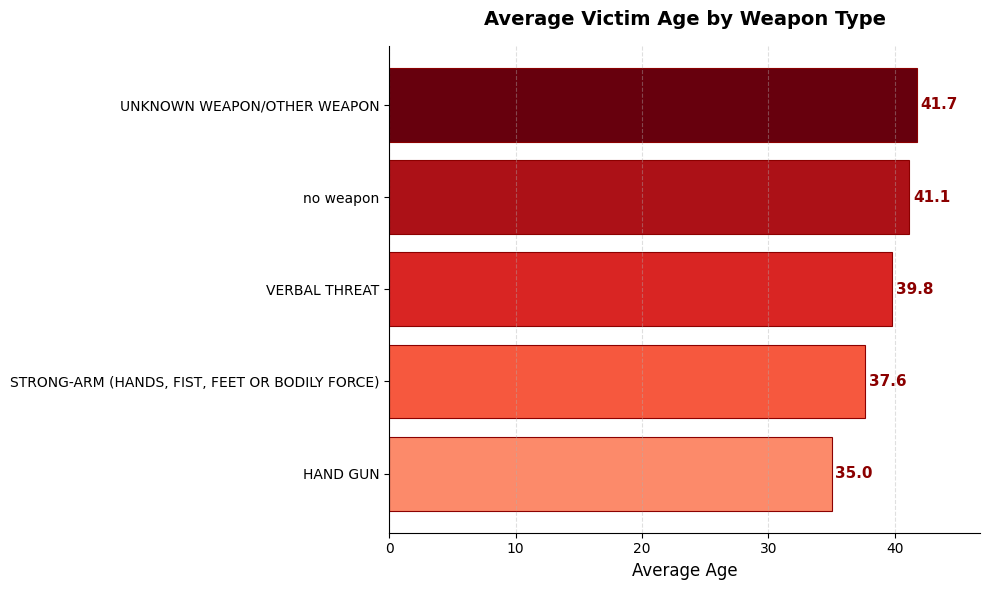

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))

data = df_filtered.groupby('Weapon Desc')['Vict Age'].mean().sort_values()
colors = plt.cm.Reds(np.linspace(0.4, 1, len(data)))

bars = ax.barh(data.index, data.values, color=colors, edgecolor='darkred', linewidth=0.8)

# Add value labels
for bar, val in zip(bars, data.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=11, fontweight='bold', color='darkred')

ax.set_title('Average Victim Age by Weapon Type', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Average Age', fontsize=12)
ax.set_ylabel('')
ax.set_xlim(0, data.max() + 5)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()